In [1]:
## Notebook for downloading SWOT L3 version 3 data
## created on April 22, 2026
## Anup Nambiathody


In [17]:
## Before downloading make sure you have AVISO+ credentials
#If you are not registered please follow the link to register
# (https://www.aviso.altimetry.fr/en/data/data-access/registration-form.html).

## Make sure you know the pass numbers of the SWOT 
## This code downloads the SWOT data pass number 270 and plots the mean sea surface for the entire pass

In [2]:
from getpass import getpass
import os
import ftplib
import pandas as pd

In [3]:
## this is the function to download SWOT data.
def download_swot(
    ftp_path,
    level,
    variant,
    passes,
    output_dir,
    cycle_numbers=None,     
    cycle_range=None,       
    only_last=True
):
    ftp_host = "ftp-access.aviso.altimetry.fr"
    os.makedirs(output_dir, exist_ok=True)

    with ftplib.FTP(ftp_host) as ftp:
        ftp.login(username, password)
        ftp.cwd(ftp_path)
        print("Connected:", ftp.getwelcome())

        # ---- DETECT AVAILABLE CYCLES ----
        all_dirs = ftp.nlst()
        available_cycles = sorted([
            int(d.split("_")[1])
            for d in all_dirs if d.startswith("cycle_")
        ])

        # ---- SELECT CYCLES ----
        if cycle_numbers == "all":
            selected_cycles = available_cycles

        elif cycle_range is not None:
            start, end = cycle_range
            selected_cycles = [c for c in available_cycles if start <= c <= end]

        elif cycle_numbers is not None:
            selected_cycles = cycle_numbers

        else:
            raise ValueError("Provide cycle_numbers, cycle_range, or 'all'")

        print(f"cycle numbers: {selected_cycles}")

        downloaded_files = []

        for cycle in selected_cycles:
            cycle_str = f"{cycle:03d}"
            cycle_dir = f"cycle_{cycle_str}"

            try:
                ftp.cwd(cycle_dir)
            except:
                print(f"Skipping {cycle_dir}")
                continue

            print(f"\nCycle {cycle_str}")
            files = ftp.nlst()

            for p in passes:
                pass_str = f"{p:03d}"

                matched = [
                    f for f in files
                    if f.startswith(f"SWOT_{level}_LR_SSH_{variant}_{cycle_str}_{pass_str}")
                    and f.endswith(".nc")
                ]

                if not matched:
                    print(f"No pass {pass_str}")
                    continue

                for fname in matched:
                    local_path = os.path.join(output_dir, fname)

                    if os.path.exists(local_path):
                        print(f"Skip {fname}")
                        continue

                    print(f"Downloading {fname}")
                    with open(local_path, "wb") as f:
                        ftp.retrbinary(f"RETR {fname}", f.write)

                    downloaded_files.append(local_path)

            ftp.cwd("..")

        ftp.quit()
        return downloaded_files

In [4]:
import geopandas as gpd
from shapely import geometry 

def get_half_orbits_intersect(
    bbox,
    GEOMETRIES_FILE="KaRIn_2kms_science_geometries.geojson"
):

    swath_geometries = gpd.read_file(GEOMETRIES_FILE)

    bbox_polygon = geometry.box(*bbox)

    select = swath_geometries.apply(
        lambda row: bbox_polygon.intersects(row.geometry),
        axis=1
    )

    return swath_geometries[select]

#Get the pass numbers within the region of the interest
# Here the region US east coast is selected

bbox = (-85, 20, -55, 50)  # (lon_min, lat_min, lon_max, lat_max)

geoms = get_half_orbits_intersect(bbox)

valid_passes = sorted(geoms["pass_number"].unique())
print("There are", len(valid_passes), "passes")
df_passes = pd.DataFrame({"passes": valid_passes})
#df_passes

There are 53 passes


In [5]:
# AVISO login credentials
## input user name and password
username = input("Enter FTP username: ")
password = getpass("Enter FTP password: ")

In [6]:
# FTP paths
ftp_paths = {
    1: "/swot_products/l3_karin_nadir/l3_lr_ssh/v3_0/Basic/reproc/",
    2: "/swot_products/l3_karin_nadir/l3_lr_ssh/v3_0/Expert/reproc/",
    3: "swot_products/l3_karin_nadir/l3_lr_ssh/v3_0/Technical/reproc/",
    4: "/swot_products/l3_karin_nadir/l3_lr_ssh/v2_0_1/Unsmoothed/"}

variants = {1: "Basic",2: "Expert",3:"Technical",4:"Unsmoothed"}

In [ ]:
# input your which product you want 
# 1 = Basic, 
# 2 = Expert
# 3= Technical 
# 4= Unsmoothed

inp = 2   # any numbers between 1 and 4 see above for options
ftp_path = ftp_paths[inp]
variant = variants[inp]

## Download data either by indiviual passes numbers or all passes with the bounding box
# If passes to download is None it download all passes within the box
# else select the list of passses you wish to download

passes_to_download = [270]  # 270 for Woodshole

if passes_to_download is None:
    passes = list(df_passes['passes'])
else:
    passes = passes_to_download

files = download_swot(
    ftp_path=ftp_path,
    level="L3",
    variant=variant,
    passes=passes,
    cycle_numbers=list(range(474,577)), #calval
    output_dir="/Users/anupn/Desktop/work/swot/data/calval/expert"
)

Connected: 220 192.168.10.119 FTP server ready
cycle numbers: [474, 475, 476, 477, 478, 479, 480, 481, 482, 483, 484, 485, 486, 487, 488, 489, 490, 491, 492, 493, 494, 495, 496, 497, 498, 499, 500, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512, 513, 514, 515, 516, 517, 518, 519, 520, 521, 522, 523, 524, 525, 526, 527, 528, 529, 530, 531, 532, 533, 534, 535, 536, 537, 538, 539, 540, 541, 542, 543, 544, 545, 546, 547, 548, 549, 550, 551, 552, 553, 554, 555, 556, 557, 558, 559, 560, 561, 562, 563, 564, 565, 566, 567, 568, 569, 570, 571, 572, 573, 574, 575, 576]

Cycle 474
Skip SWOT_L3_LR_SSH_Expert_474_015_20230329T095725_20230329T104830_v3.0.nc

Cycle 475
No pass 015

Cycle 476

Cycle 477
No pass 015

Cycle 478

Cycle 479

Cycle 480

Cycle 481

Cycle 482

Cycle 483

Cycle 484

Cycle 485

Cycle 486

Cycle 487

Cycle 488

Cycle 489

Cycle 490

Cycle 491

Cycle 492

Cycle 493

Cycle 494

Cycle 495

Cycle 496

Cycle 497

Cycle 498

Cycle 499

Cycle 500

Cycle 501

Cycle 502

Cyc

In [ ]:
# input your which product you want 
# 1 = Basic, 
# 2 = Expert
# 3= Technical 
# 4= Unsmoothed

inp = 2   # any numbers between 1 and 4 see above for options

ftp_path = ftp_paths[inp]
variant = variants[inp]


files = download_swot(
    ftp_path=ftp_path,
    level="L3",
    variant=variant,

    passes = list(df_passes['passes'])
    passes=[15],   # input any number of passes you wish to download
    cycle_numbers = list(range(507, 511)), #cycle_numbers= [1] # cycle_numbers="all" for getting all the cycles
    #output_dir="./swot_data/expert/"
    output_dir="/Users/anupn/Desktop/summer_school/swot_data/expert/"
)

Connected: 220 192.168.10.119 FTP server ready
cycle numbers: [507, 508, 509, 510]

Cycle 507

Cycle 508

Cycle 509

Cycle 510


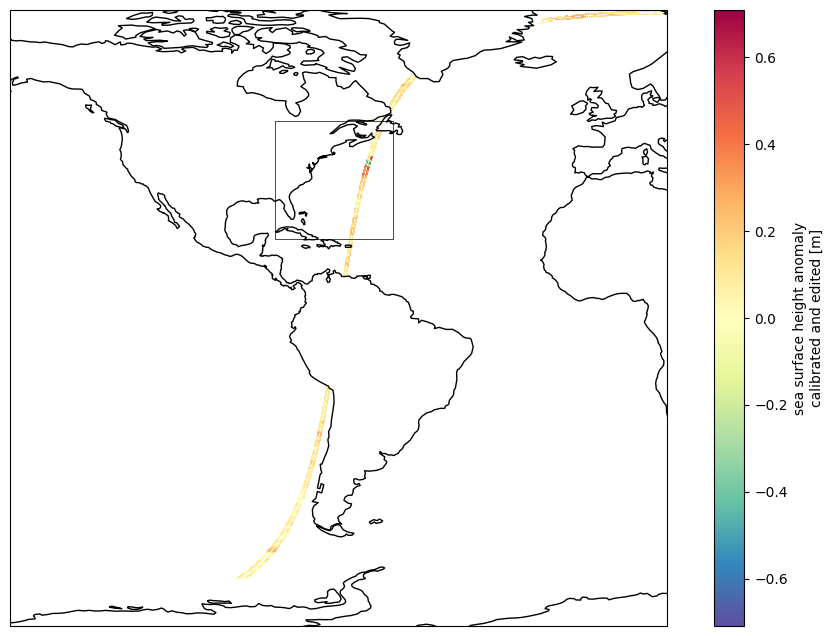

In [ ]:
## visualise the downloaded path
import matplotlib.patches as patches
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

ds = xr.open_dataset("data/SWOT_L3_LR_SSH_Basic_001_201_20230728T090311_20230728T095437_v3.0.nc")
fig, ax = plt.subplots( figsize=(12, 8),
                               subplot_kw=dict(projection=ccrs.PlateCarree()))
ds['ssha_unfiltered'].plot.pcolormesh(ax=ax,x="longitude",y="latitude",cmap="Spectral_r")
square = patches.Rectangle(
        (bbox[0], bbox[1]),
        bbox[2] - bbox[0],
        bbox[3] - bbox[1],edgecolor="black",facecolor="none",linewidth=0.5,transform=ccrs.PlateCarree())
ax.add_patch(square)
ax.coastlines()
#ax.set_extent(bbox)
plt.show()

In [57]:
# import geopandas as gpd
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
# from shapely import geometry
# import matplotlib.patches as patches


# def plot_swot_swaths(
#     bbox,
#     GEOMETRIES_FILE="KaRIn_2kms_science_geometries.geojson",
#     title="SWOT Half-Orbits Intersecting Region"
# ):

#     #  load swath geometries
#     swath_geometries = gpd.read_file(GEOMETRIES_FILE)

#     #  bounding box (lon_min, lat_min, lon_max, lat_max)
#     bbox_polygon = geometry.box(*bbox)

#     #  filter intersecting swaths
#     select = swath_geometries.apply(
#         lambda row: bbox_polygon.intersects(row.geometry),
#         axis=1
#     )

#     selected = swath_geometries[select]

#     #  plot
#     fig, ax = plt.subplots(
#         figsize=(12, 8),
#         subplot_kw={"projection": ccrs.PlateCarree()}
#     )

#     #  swath geometries
#     gpd.GeoSeries(selected.geometry).plot(
#         ax=ax,
#         transform=ccrs.PlateCarree(),
#         alpha=0.7,
#         color="blue"
#     )

#     #  region box
#     square = patches.Rectangle(
#         (bbox[0], bbox[1]),
#         bbox[2] - bbox[0],
#         bbox[3] - bbox[1],
#         edgecolor="orange",
#         facecolor="none",
#         linewidth=2,
#         transform=ccrs.PlateCarree()
#     )
#     ax.add_patch(square)


#     ax.coastlines()
#     ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.5)

#     ax.set_extent([bbox[0]-10, bbox[2]+10, bbox[1]-10, bbox[3]+10])

#     ax.set_title(title)

#     plt.show()




# plot_swot_swaths(bbox)